In [8]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
df=pd.read_excel('Bariatric Project Study Data 2025_mod.xlsx', sheet_name='Sheet1')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Select core features
core_X_data = df[['gender', 'age', 'height', 'weight', 'bmi', 'family_hist_cnt', 
                  'chronic_meds_cnt', 'procedure_category', 'antibiotics']].copy()

# Filter CM_ columns and drop those with only zeros
cm_cols = [col for col in df.columns if col.startswith('CM_')]
cm_data = df[cm_cols].fillna(0).astype(int)
zero_only = [col for col in cm_data.columns if (cm_data[col] == 0).all()]
cm_data = cm_data.drop(columns=zero_only)

# Join filtered CM_ data back into the core dataset
core_X_data = core_X_data.join(cm_data)
core_X_data.fillna(0, inplace=True)

# Print summary of dropped and remaining CM_ columns
print("Dropped CM columns:", zero_only)
print("Remaining columns in CM data:", cm_data.columns.tolist())

# Analyze antibiotic dummy columns
ab_cols = [col for col in core_X_data.columns if col.startswith('antibiotics')]

# Count zeros in each antibiotic column
for col in ab_cols:
    n_zeros = (core_X_data[col] == 0).sum()
    print(f"{col}: {n_zeros} zeros out of {len(core_X_data)} rows")

# Count rows with no antibiotics flagged
no_ab_rows = (core_X_data[ab_cols].sum(axis=1) == 0).sum()
print(f"\nRows where ALL antibiotic dummies are 0: {no_ab_rows}")


Dropped CM columns: ['CM_ALCOHOL', 'CM_BLDLOSS', 'CM_CHRNLUNG', 'CM_COAG', 'CM_DRUG', 'CM_LYMPH', 'CM_LYTES', 'CM_METS', 'CM_NEURO', 'CM_PARA', 'CM_PERIVASC', 'CM_PULMCIRC', 'CM_RENLFAIL', 'CM_TUMOR', 'CM_ULCER', 'CM_VALVE', 'CM_WGHTLOSS']
Remaining columns in CM data: ['CM_AIDS', 'CM_ANEMDEF', 'CM_ARTH', 'CM_CHF', 'CM_DEPRESS', 'CM_DM', 'CM_DMCX', 'CM_HTN_C', 'CM_HYPOTHY', 'CM_LIVER', 'CM_OBESE', 'CM_PSYCH', 'CM_SMOKE', 'CM_APNEA', 'CM_CHOLSTRL', 'CM_OSTARTH', 'CM_HPLD']
antibiotics: 4 zeros out of 344 rows

Rows where ALL antibiotic dummies are 0: 4


In [5]:
# Identify complication-related columns
comp_cols = [col for col in df.columns if 'comp' in col.lower()]

# Create a new dataset excluding the original complication columns
df_new = df.drop(columns=comp_cols)

# Add a single 'complication' column: 1 if any original complication column equals 1, else 0
df_new['complication'] = df[comp_cols].any(axis=1).astype(int)

# Display the new dataset shape and a sample of the 'complication' column
print(f"New dataset shape: {df_new.shape}")
print(df_new[['id', 'complication']].head(10))
print("First 15 column names:", df_new.columns[:15].tolist())


New dataset shape: (344, 111)
        id  complication
0  45488.0             0
1      NaN             0
2  37462.0             1
3  40661.0             0
4      NaN             0
5  40699.0             0
6  38920.0             0
7  37827.0             0
8  47189.0             1
9      NaN             0
First 15 column names: ['doctor', 'procedure_category', 'hospitalDesc', 'hospital_wardDesc', 'days_since_admission', 'length_of_stay', 'gender', 'age', 'weight', 'height', 'bmi', 'family_hist_cnt', 'chronic_meds_cnt', 'cm_count', 'morbidity']


In [6]:
# Missing values analysis
missing_df = core_X_data.isnull().sum().to_frame(name='Missing_Count')
missing_df['Missing_Percentage'] = (missing_df['Missing_Count'] / len(core_X_data)) * 100
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

print("=" * 50)
print("MISSING VALUES ANALYSIS")
print("=" * 50)
print(f"Columns with missing values: {len(missing_df)}/{core_X_data.shape[1]}")
total_completeness = 100 * (1 - core_X_data.isnull().sum().sum() / (core_X_data.shape[0] * core_X_data.shape[1]))
print(f"Total completeness: {total_completeness:.1f}%")

if not missing_df.empty:
    print("\nTop missing columns:")
    print(missing_df.head(10))
    
    # Visualization
    plt.figure(figsize=(10, 6))
    top_missing = missing_df.head(15)
    plt.barh(top_missing.index, top_missing['Missing_Percentage'], color='coral')
    plt.xlabel('Missing Percentage (%)')
    plt.title('Top 15 Columns with Missing Values', fontsize=14, fontweight='bold')
    
    for i, v in enumerate(top_missing['Missing_Percentage']):
        plt.text(v + 0.1, i, f'{v:.1f}%', va='center')
    
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found!")


MISSING VALUES ANALYSIS
Columns with missing values: 0/26
Total completeness: 100.0%
No missing values found!


In [7]:
core_Y_data=df_new[["complication"]]

core_Y_data.head()

,complication
0,0
1,0
2,1
3,0
4,0


In [9]:
# Prepare data
X = core_X_data.copy()
y = core_Y_data['complication'].values

# Encode categorical variables
categorical_cols = X.select_dtypes(include=['object']).columns
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# Display class distribution
print("Class distribution in training set:")
print(f"No complications: {(y_train == 0).sum()} ({(y_train == 0).mean() * 100:.1f}%)")
print(f"Complications: {(y_train == 1).sum()} ({(y_train == 1).mean() * 100:.1f}%)")

print("\nClass distribution in test set:")
print(f"No complications: {(y_test == 0).sum()} ({(y_test == 0).mean() * 100:.1f}%)")
print(f"Complications: {(y_test == 1).sum()} ({(y_test == 1).mean() * 100:.1f}%)")

X_encoded.head()

Class distribution in training set:
No complications: 247 (89.8%)
Complications: 28 (10.2%)

Class distribution in test set:
No complications: 62 (89.9%)
Complications: 7 (10.1%)


,age,height,weight,bmi,family_hist_cnt,chronic_meds_cnt,CM_AIDS,CM_ANEMDEF,CM_ARTH,CM_CHF,...,procedure_category_BPD -DS,procedure_category_Mini gastric bypass (OAGB),procedure_category_RYGBP,procedure_category_SADI,procedure_category_Sleeve,antibiotics_Augmentin,antibiotics_Clindamycin,antibiotics_Invanz,antibiotics_Kefsol,antibiotics_Rocephin
0,50,154,146.0,61.56,0,0,0,0,0,0,...,False,False,False,True,False,False,False,False,True,False
1,52,168,96.0,34.00,0,0,0,0,0,0,...,False,False,False,False,True,False,False,False,True,False
2,23,163,143.0,53.82,0,0,0,0,0,0,...,False,False,False,True,False,False,False,False,True,False
3,23,176,120.0,38.74,0,0,0,0,0,0,...,False,False,False,False,True,False,False,False,True,False
4,57,162,112.0,42.68,0,7,0,0,0,0,...,False,False,False,True,False,False,False,False,True,False


In [25]:
print("Here is a list of all the features that we are planning to use for input into the AI model")
for col in X_encoded.columns:
    print(col)

Here is a list of all the features that we are planning to use for input into the AI model
age
height
weight
bmi
family_hist_cnt
chronic_meds_cnt
CM_AIDS
CM_ANEMDEF
CM_ARTH
CM_CHF
CM_DEPRESS
CM_DM
CM_DMCX
CM_HTN_C
CM_HYPOTHY
CM_LIVER
CM_OBESE
CM_PSYCH
CM_SMOKE
CM_APNEA
CM_CHOLSTRL
CM_OSTARTH
CM_HPLD
gender_Male
procedure_category_BPD -DS
procedure_category_Mini gastric bypass (OAGB)
procedure_category_RYGBP
procedure_category_SADI
procedure_category_Sleeve
antibiotics_Augmentin
antibiotics_Clindamycin
antibiotics_Invanz
antibiotics_Kefsol
antibiotics_Rocephin


Smote Logistic Regression


In [13]:
from imblearn.over_sampling import (
    SMOTE, 
    BorderlineSMOTE, 
    SVMSMOTE, 
    ADASYN,
    RandomOverSampler,
    KMeansSMOTE
)
from imblearn.combine import SMOTEENN, SMOTETomek
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from sklearn.metrics import precision_recall_curve
from imblearn.pipeline import Pipeline as ImbPipeline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

# Define all oversampling methods
oversampling_methods = {
    'SMOTE (Original)': SMOTE(random_state=42),
    'Borderline-SMOTE': BorderlineSMOTE(random_state=102),
    'SVM-SMOTE': SVMSMOTE(random_state=102),
    'ADASYN': ADASYN(random_state=42),
    'Random OverSampling': RandomOverSampler(random_state=102),
    'KMeans-SMOTE': KMeansSMOTE(random_state=102, n_jobs=-1),
    'SMOTE + ENN': SMOTEENN(random_state=100),
    'SMOTE + Tomek': SMOTETomek(random_state=102)
}

# Store results
results = {}
smote_original_pipeline = None  # <-- Store this separately for saving

print("="*80)
print("COMPARING ALL OVERSAMPLING METHODS")
print("="*80)

for name, sampler in oversampling_methods.items():
    print(f"\nTesting: {name}")
    print("-"*50)
    
    start_time = time.time()
    
    try:
        # Create pipeline
        pipeline = ImbPipeline([
            ('scaler', StandardScaler()),
            ('sampler', sampler),
            ('classifier', LogisticRegression(random_state=42, max_iter=1000))
        ])
        
        # Fit the model
        pipeline.fit(X_train, y_train)

        # Save pipeline if it's the original SMOTE
        if name == 'SMOTE (Original)':
            smote_original_pipeline = pipeline
        
        # Get predictions
        y_pred = pipeline.predict(X_test)
        y_proba = pipeline.predict_proba(X_test)[:, 1]
        
        # Calculate metrics
        roc_auc = roc_auc_score(y_test, y_proba)
        cm = confusion_matrix(y_test, y_pred)
        tn, fp, fn, tp = cm.ravel()
        
        # Calculate optimal threshold
        precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
        f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
        optimal_idx = np.argmax(f1_scores)
        optimal_threshold = thresholds[optimal_idx] if optimal_idx < len(thresholds) else 0.5
        
        # Apply optimal threshold
        y_pred_optimal = (y_proba >= optimal_threshold).astype(int)
        cm_optimal = confusion_matrix(y_test, y_pred_optimal)
        tn_opt, fp_opt, fn_opt, tp_opt = cm_optimal.ravel()
        
        # Store results
        results[name] = {
            'roc_auc': roc_auc,
            'default_sensitivity': tp / (tp + fn),
            'default_specificity': tn / (tn + fp),
            'optimal_threshold': optimal_threshold,
            'optimal_sensitivity': tp_opt / (tp_opt + fn_opt),
            'optimal_specificity': tn_opt / (tn_opt + fp_opt),
            'optimal_f1': f1_scores[optimal_idx],
            'time': time.time() - start_time,
            'y_proba': y_proba,
            'precision_recall': (precision, recall, thresholds)
        }
        
        print(f"ROC-AUC: {roc_auc:.3f}")
        print(f"Default threshold (0.5): Sens={tp/(tp+fn):.1%}, Spec={tn/(tn+fp):.1%}")
        print(f"Optimal threshold ({optimal_threshold:.3f}): Sens={tp_opt/(tp_opt+fn_opt):.1%}, "
              f"Spec={tn_opt/(tn_opt+fp_opt):.1%}, F1={f1_scores[optimal_idx]:.3f}")
        
    except Exception as e:
        print(f"Error with {name}: {str(e)}")
        results[name] = None

COMPARING ALL OVERSAMPLING METHODS

Testing: SMOTE (Original)
--------------------------------------------------
ROC-AUC: 0.677
Default threshold (0.5): Sens=57.1%, Spec=62.9%
Optimal threshold (0.684): Sens=57.1%, Spec=80.6%, F1=0.348

Testing: Borderline-SMOTE
--------------------------------------------------
ROC-AUC: 0.680
Default threshold (0.5): Sens=42.9%, Spec=69.4%
Optimal threshold (0.885): Sens=42.9%, Spec=88.7%, F1=0.353

Testing: SVM-SMOTE
--------------------------------------------------
ROC-AUC: 0.677
Default threshold (0.5): Sens=42.9%, Spec=71.0%
Optimal threshold (0.818): Sens=42.9%, Spec=91.9%, F1=0.400

Testing: ADASYN
--------------------------------------------------
ROC-AUC: 0.668
Default threshold (0.5): Sens=57.1%, Spec=64.5%
Optimal threshold (0.698): Sens=57.1%, Spec=79.0%, F1=0.333

Testing: Random OverSampling
--------------------------------------------------
ROC-AUC: 0.650
Default threshold (0.5): Sens=57.1%, Spec=64.5%
Optimal threshold (0.651): Sens=57

In [14]:
X_encoded.head()

,age,height,weight,bmi,family_hist_cnt,chronic_meds_cnt,CM_AIDS,CM_ANEMDEF,CM_ARTH,CM_CHF,...,procedure_category_BPD -DS,procedure_category_Mini gastric bypass (OAGB),procedure_category_RYGBP,procedure_category_SADI,procedure_category_Sleeve,antibiotics_Augmentin,antibiotics_Clindamycin,antibiotics_Invanz,antibiotics_Kefsol,antibiotics_Rocephin
0,50,154,146.0,61.56,0,0,0,0,0,0,...,False,False,False,True,False,False,False,False,True,False
1,52,168,96.0,34.00,0,0,0,0,0,0,...,False,False,False,False,True,False,False,False,True,False
2,23,163,143.0,53.82,0,0,0,0,0,0,...,False,False,False,True,False,False,False,False,True,False
3,23,176,120.0,38.74,0,0,0,0,0,0,...,False,False,False,False,True,False,False,False,True,False
4,57,162,112.0,42.68,0,7,0,0,0,0,...,False,False,False,True,False,False,False,False,True,False


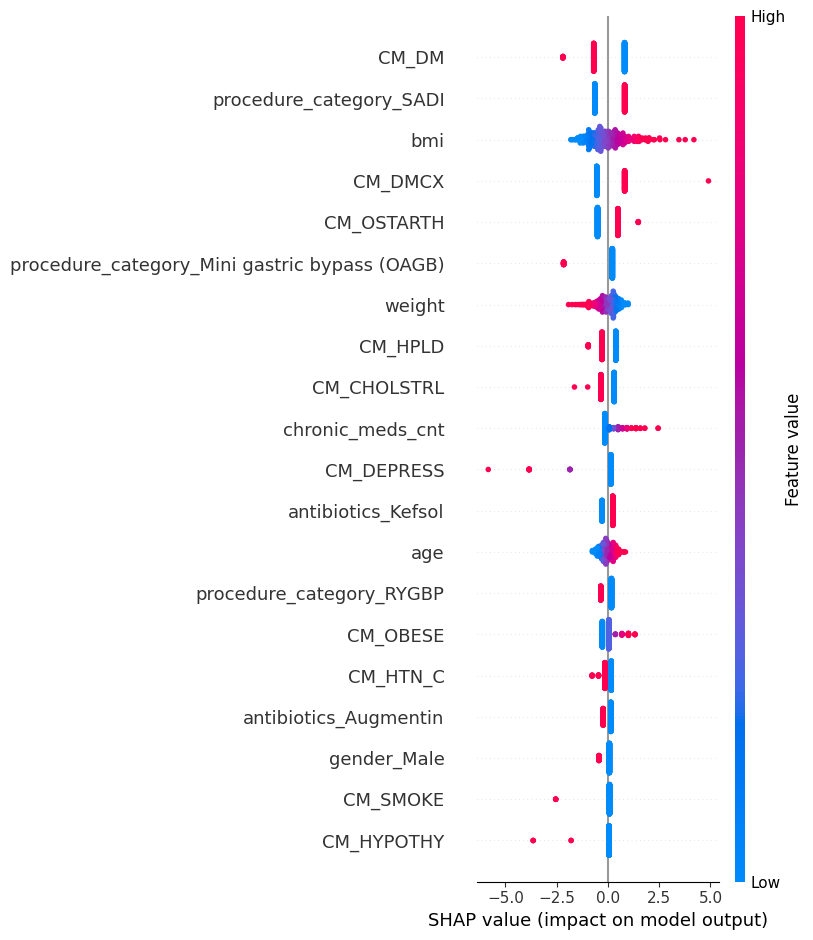

In [15]:
import shap

# 1. Extract the scaler and trained classifier from the pipeline
scaler = smote_original_pipeline.named_steps['scaler']
classifier = smote_original_pipeline.named_steps['classifier']

# 2. Scale the real data (same preprocessing the model was trained on)
core_X_scaled = scaler.transform(X_encoded)

# 3. Create SHAP explainer for linear model
explainer = shap.Explainer(classifier, core_X_scaled)

# 4. Compute SHAP values
shap_values = explainer(core_X_scaled)

# 5. Plot summary of feature importance
shap.summary_plot(shap_values, X_encoded, feature_names=X_encoded.columns)

In [16]:
for i, name in enumerate(core_X_data.columns):
    print(f"Feature {i} = {name}")

Feature 0 = gender
Feature 1 = age
Feature 2 = height
Feature 3 = weight
Feature 4 = bmi
Feature 5 = family_hist_cnt
Feature 6 = chronic_meds_cnt
Feature 7 = procedure_category
Feature 8 = antibiotics
Feature 9 = CM_AIDS
Feature 10 = CM_ANEMDEF
Feature 11 = CM_ARTH
Feature 12 = CM_CHF
Feature 13 = CM_DEPRESS
Feature 14 = CM_DM
Feature 15 = CM_DMCX
Feature 16 = CM_HTN_C
Feature 17 = CM_HYPOTHY
Feature 18 = CM_LIVER
Feature 19 = CM_OBESE
Feature 20 = CM_PSYCH
Feature 21 = CM_SMOKE
Feature 22 = CM_APNEA
Feature 23 = CM_CHOLSTRL
Feature 24 = CM_OSTARTH
Feature 25 = CM_HPLD


In [18]:
cm_features = [col for col in X_encoded.columns if col.startswith("CM_")]

for cm in cm_features:
    total_count = X_encoded[cm].sum()
    comp_count = X_encoded[y == 1][cm].sum()
    print(f"{cm:<15} → Total: {total_count}, In complications: {comp_count}")

CM_AIDS         → Total: 8, In complications: 0
CM_ANEMDEF      → Total: 1, In complications: 0
CM_ARTH         → Total: 3, In complications: 0
CM_CHF          → Total: 2, In complications: 0
CM_DEPRESS      → Total: 26, In complications: 0
CM_DM           → Total: 185, In complications: 14
CM_DMCX         → Total: 145, In complications: 13
CM_HTN_C        → Total: 191, In complications: 19
CM_HYPOTHY      → Total: 8, In complications: 0
CM_LIVER        → Total: 83, In complications: 5
CM_OBESE        → Total: 281, In complications: 36
CM_PSYCH        → Total: 1, In complications: 0
CM_SMOKE        → Total: 8, In complications: 0
CM_APNEA        → Total: 176, In complications: 11
CM_CHOLSTRL     → Total: 162, In complications: 14
CM_OSTARTH      → Total: 174, In complications: 15
CM_HPLD         → Total: 187, In complications: 13


In [20]:
import numpy as np
shap_means = np.abs(shap_values.values).mean(axis=0)
shap_df = pd.DataFrame({
    "feature": X_encoded.columns,
    "mean_abs_shap": shap_means
}).sort_values(by="mean_abs_shap", ascending=False)

# Show only CM_ features
shap_df[shap_df['feature'].str.startswith("CM_")]

,feature,mean_abs_shap
11,CM_DM,0.799416
12,CM_DMCX,0.669025
21,CM_OSTARTH,0.514553
22,CM_HPLD,0.360247
20,CM_CHOLSTRL,0.326914
10,CM_DEPRESS,0.277809
16,CM_OBESE,0.218694
13,CM_HTN_C,0.175428
18,CM_SMOKE,0.107451
14,CM_HYPOTHY,0.096946


In [21]:
cm_to_remove = [
    "CM_AIDS",
    "CM_ANEMDEF",
    "CM_ARTH",
    "CM_CHF",
    "CM_DEPRESS",
    "CM_HYPOTHY",
    "CM_PSYCH",
    "CM_SMOKE"
]

Explanation for removal:

Feature	| Total Count	| In Complications	| SHAP Mean	| Interpretation

CM_DMCX	145	13	1.91	🔥 Very high SHAP + medium count = keep

CM_DM	185	14	1.27	✅ Important and well-represented → keep

CM_DEPRESS	26	0	0.28	⚠️ Suspicious: high SHAP but never in positive → remove

CM_SMOKE	8	0	0.20	❌ Very low count, never in positive → remove

CM_AIDS	8	0	0.04	❌ Same → remove

CM_PSYCH	1	0	0.01	❌ Definitely remove

CM_CHF	2	0	0.00	❌ Definitely remove

CM_ANEMDEF	1	0	0.00	❌ Definitely remove

CM_ARTH	3	0	0.06	❌ Low count, no impact → remove

CM_HYPOTHY	8	0	0.10	❌ Borderline, but still remove

CM_LIVER	83	5	0.18	✅ Keep

CM_CHOLSTRL	162	14	0.78	✅ Keep

CM_OSTARTH	174	15	0.38	✅ Keep

CM_HPLD	187	13	0.49	✅ Keep

CM_OBESE	281	36	0.30	✅ Keep

CM_HTN_C	191	19	0.20	✅ Keep

CM_APNEA	176	11	0.15	✅ Keep



In [22]:
X_encoded_washed = X_encoded.drop(columns=cm_to_remove)

In [23]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded_washed, y, test_size=0.2, random_state=42, stratify=y
)

print("Class distribution in training set:")
print(f"No complications: {(y_train==0).sum()} ({(y_train==0).sum()/len(y_train)*100:.1f}%)")
print(f"Complications: {(y_train==1).sum()} ({(y_train==1).sum()/len(y_train)*100:.1f}%)")
print(f"\nClass distribution in test set:")
print(f"No complications: {(y_test==0).sum()} ({(y_test==0).sum()/len(y_test)*100:.1f}%)")
print(f"Complications: {(y_test==1).sum()} ({(y_test==1).sum()/len(y_test)*100:.1f}%)")
X_encoded_washed.head()

Class distribution in training set:
No complications: 247 (89.8%)
Complications: 28 (10.2%)

Class distribution in test set:
No complications: 62 (89.9%)
Complications: 7 (10.1%)


,age,height,weight,bmi,family_hist_cnt,chronic_meds_cnt,CM_DM,CM_DMCX,CM_HTN_C,CM_LIVER,...,procedure_category_BPD -DS,procedure_category_Mini gastric bypass (OAGB),procedure_category_RYGBP,procedure_category_SADI,procedure_category_Sleeve,antibiotics_Augmentin,antibiotics_Clindamycin,antibiotics_Invanz,antibiotics_Kefsol,antibiotics_Rocephin
0,50,154,146.0,61.56,0,0,1,1,1,0,...,False,False,False,True,False,False,False,False,True,False
1,52,168,96.0,34.00,0,0,1,0,1,0,...,False,False,False,False,True,False,False,False,True,False
2,23,163,143.0,53.82,0,0,0,0,0,0,...,False,False,False,True,False,False,False,False,True,False
3,23,176,120.0,38.74,0,0,0,0,0,0,...,False,False,False,False,True,False,False,False,True,False
4,57,162,112.0,42.68,0,7,0,0,0,0,...,False,False,False,True,False,False,False,False,True,False


In [105]:
for col in X_encoded_washed.columns:
    print(col)

age
height
weight
bmi
family_hist_cnt
chronic_meds_cnt
CM_DM
CM_DMCX
CM_HTN_C
CM_LIVER
CM_OBESE
CM_APNEA
CM_CHOLSTRL
CM_OSTARTH
CM_HPLD
gender_Male
procedure_category_BPD -DS
procedure_category_Mini gastric bypass (OAGB)
procedure_category_RYGBP
procedure_category_SADI
procedure_category_Sleeve
antibiotics_Augmentin
antibiotics_Clindamycin
antibiotics_Invanz
antibiotics_Kefsol
antibiotics_Rocephin


In linear models like Logistic Regression:

	•	Redundant features can cause multicollinearity, making it harder for the model to assign meaningful weights.
	
	•	It may lead to overfitting, confusing interpretation, and instability in SHAP values.

height and weight are redundant because BMI already explains their relation

In [26]:
X_encoded_washed_2 = X_encoded_washed.drop(columns=['height', 'weight'])

In [27]:
X_encoded_washed.shape

(344, 26)

In [28]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded_washed_2, y, test_size=0.2, random_state=42, stratify=y
)

print("Class distribution in training set:")
print(f"No complications: {(y_train==0).sum()} ({(y_train==0).sum()/len(y_train)*100:.1f}%)")
print(f"Complications: {(y_train==1).sum()} ({(y_train==1).sum()/len(y_train)*100:.1f}%)")
print(f"\nClass distribution in test set:")
print(f"No complications: {(y_test==0).sum()} ({(y_test==0).sum()/len(y_test)*100:.1f}%)")
print(f"Complications: {(y_test==1).sum()} ({(y_test==1).sum()/len(y_test)*100:.1f}%)")
X_encoded_washed_2.head()

Class distribution in training set:
No complications: 247 (89.8%)
Complications: 28 (10.2%)

Class distribution in test set:
No complications: 62 (89.9%)
Complications: 7 (10.1%)


,age,bmi,family_hist_cnt,chronic_meds_cnt,CM_DM,CM_DMCX,CM_HTN_C,CM_LIVER,CM_OBESE,CM_APNEA,...,procedure_category_BPD -DS,procedure_category_Mini gastric bypass (OAGB),procedure_category_RYGBP,procedure_category_SADI,procedure_category_Sleeve,antibiotics_Augmentin,antibiotics_Clindamycin,antibiotics_Invanz,antibiotics_Kefsol,antibiotics_Rocephin
0,50,61.56,0,0,1,1,1,0,1,0,...,False,False,False,True,False,False,False,False,True,False
1,52,34.00,0,0,1,0,1,0,1,0,...,False,False,False,False,True,False,False,False,True,False
2,23,53.82,0,0,0,0,0,0,4,0,...,False,False,False,True,False,False,False,False,True,False
3,23,38.74,0,0,0,0,0,0,0,0,...,False,False,False,False,True,False,False,False,True,False
4,57,42.68,0,7,0,0,0,0,0,1,...,False,False,False,True,False,False,False,False,True,False


In [29]:
print('These are all the features used in the latest production-ready model')
for col in X_encoded_washed_2.columns:
    print(col)

These are all the features used in the latest production-ready model
age
bmi
family_hist_cnt
chronic_meds_cnt
CM_DM
CM_DMCX
CM_HTN_C
CM_LIVER
CM_OBESE
CM_APNEA
CM_CHOLSTRL
CM_OSTARTH
CM_HPLD
gender_Male
procedure_category_BPD -DS
procedure_category_Mini gastric bypass (OAGB)
procedure_category_RYGBP
procedure_category_SADI
procedure_category_Sleeve
antibiotics_Augmentin
antibiotics_Clindamycin
antibiotics_Invanz
antibiotics_Kefsol
antibiotics_Rocephin


In [30]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix, precision_recall_curve
from imblearn.pipeline import Pipeline as ImbPipeline
import numpy as np
import time

# Define only SMOTE
sampler = SMOTE(random_state=42)

# Store results
results = {}

print("="*80)
print("TRAINING MODEL WITH SMOTE")
print("="*80)

start_time = time.time()

try:
    # Create pipeline
    pipeline = ImbPipeline([
        ('scaler', StandardScaler()),
        ('sampler', sampler),
        ('classifier', LogisticRegression(random_state=42, max_iter=1000))
    ])
    
    # Fit the model
    pipeline.fit(X_train, y_train)
    
    # Get predictions
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    roc_auc = roc_auc_score(y_test, y_proba)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    # Calculate optimal threshold
    precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
    optimal_idx = np.argmax(f1_scores)
    optimal_threshold = thresholds[optimal_idx] if optimal_idx < len(thresholds) else 0.5
    
    # Apply optimal threshold
    y_pred_optimal = (y_proba >= optimal_threshold).astype(int)
    cm_optimal = confusion_matrix(y_test, y_pred_optimal)
    tn_opt, fp_opt, fn_opt, tp_opt = cm_optimal.ravel()
    
    # Store results
    results["SMOTE (Original)"] = {
        'roc_auc': roc_auc,
        'default_sensitivity': tp / (tp + fn),
        'default_specificity': tn / (tn + fp),
        'optimal_threshold': optimal_threshold,
        'optimal_sensitivity': tp_opt / (tp_opt + fn_opt),
        'optimal_specificity': tn_opt / (tn_opt + fp_opt),
        'optimal_f1': f1_scores[optimal_idx],
        'time': time.time() - start_time,
        'y_proba': y_proba,
        'precision_recall': (precision, recall, thresholds)
    }
    
    print(f"ROC-AUC: {roc_auc:.3f}")
    print(f"Default threshold (0.5): Sens={tp/(tp+fn):.1%}, Spec={tn/(tn+fp):.1%}")
    print(f"Optimal threshold ({optimal_threshold:.3f}): Sens={tp_opt/(tp_opt+fn_opt):.1%}, "
          f"Spec={tn_opt/(tn_opt+fp_opt):.1%}, F1={f1_scores[optimal_idx]:.3f}")
    
except Exception as e:
    print(f"Error with SMOTE (Original): {str(e)}")
    results["SMOTE (Original)"] = None

TRAINING MODEL WITH SMOTE
ROC-AUC: 0.661
Default threshold (0.5): Sens=57.1%, Spec=61.3%
Optimal threshold (0.735): Sens=57.1%, Spec=83.9%, F1=0.381


In [114]:
import joblib
joblib.dump(pipeline, 'SMOTE_logReg_risk_model.pkl')

['SMOTE_logReg_risk_model.pkl']

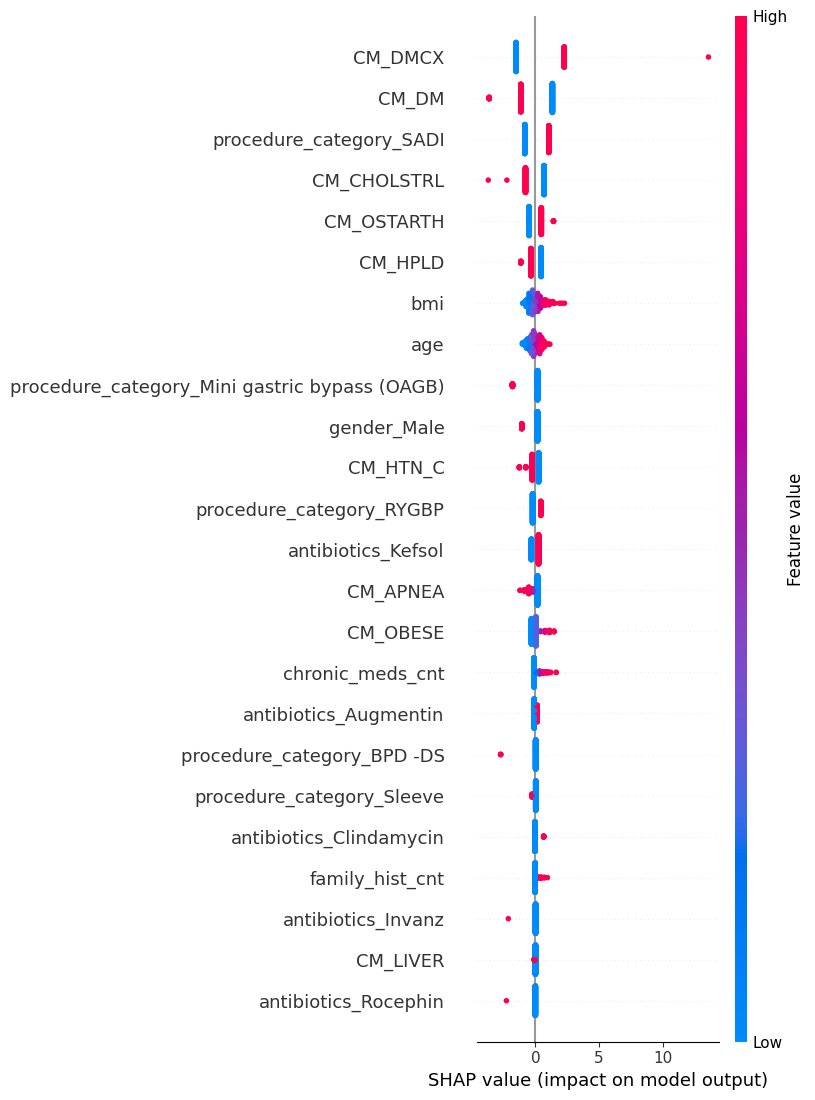

In [115]:
import shap

# Extract scaler and classifier from the trained pipeline
scaler = pipeline.named_steps['scaler']
classifier = pipeline.named_steps['classifier']

core_X_scaled = scaler.transform(X_encoded_washed_2)

explainer = shap.Explainer(classifier, core_X_scaled)
shap_values = explainer(core_X_scaled)

shap.summary_plot(
    shap_values,
    core_X_scaled,
    feature_names=X_encoded_washed_2.columns,
    max_display=X_encoded_washed_2.shape[1]
)

Evaluation AI model

In [31]:
for name, res in results.items():
    if res is None: 
        continue
    thr     = res['optimal_threshold']
    y_pred  = (res['y_proba'] >= thr).astype(int)
    print(f"\n=== {name} (thr={thr:.3f}) ===")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))



=== SMOTE (Original) (thr=0.735) ===
[[52 10]
 [ 3  4]]
              precision    recall  f1-score   support

           0       0.95      0.84      0.89        62
           1       0.29      0.57      0.38         7

    accuracy                           0.81        69
   macro avg       0.62      0.71      0.63        69
weighted avg       0.88      0.81      0.84        69

